# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [234]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [235]:
# cargar archivos
plans = pd.read_csv("/datasets/plans.csv")
users = pd.read_csv("/datasets/users_latam.csv")
usage = pd.read_csv("/datasets/usage.csv")

In [236]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [237]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [238]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [239]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [240]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [241]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [242]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [243]:
# cantidad de nulos para users
print(f"Cantidad de valores nulos en Users: {users.isna().sum()}")
print(f"Proporción de valores nulos en Users: {users.isna().mean()}")

Cantidad de valores nulos en Users: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos en Users: user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [244]:
# cantidad de nulos para usage
print(f"Cantidad de valores nulos para Usage: {usage.isna().sum()}")
print(f"Proporción de valores nulos para Usage: {usage.isna().mean()}")

Cantidad de valores nulos para Usage: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos para Usage: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos - Users**  
- La columna churn_date refleja un 88% de valores nulos, sin embargo, considerando que esta indica la fecha de cancelación podemos ignorarla, ya que al poseer un valor nulo nos indica que un cliente sigue activo y adicionalmente, los clientes que poseen un valor en esta columna cuentan con registros entre 2022 y 2024 que son valiosos para el analisis.
- 
  
**Valores nulos - Usage**  

- Los valores nulos en la columna date son mínimos, lo que nos permite dejarlos como nulos 
- En esta fuente, las columnas que más destacan por sus valores nulos son 'duration' y 'lenght', sin embargo, al comprender la naturaleza de estos datos y su relación con la columna 'type' no podemos imputar o amputar, por lo que la mejor opción es mantenerlos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [245]:
users[["user_id","age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [246]:
usage[["id","user_id"]].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [247]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(f"Descripción: \n{users[columnas_user].describe()}")
print()
print(f"Frecuencia de ciudades únicas: \n{users['city'].value_counts()}\nFrecuencia de planes únicos:\n{users['plan'].value_counts()}")
print()
print(f"Frecuencia de valores únicos: \n{users[columnas_user].value_counts(normalize=True)}")

Descripción: 
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Frecuencia de ciudades únicas: 
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia de planes únicos:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Frecuencia de valores únicos: 
city      plan   
Bogotá    Basico     0.147833
CDMX      Basico     0.134240
Medellín  Basico     0.112716
GDL       Basico     0.084395
Bogotá    Premium    0.080997
MTY       Basico     0.077882
Cali      Basico     0.074200
CDMX      Premium    0.072501
Medellín  Premium    0.061739
Cali      Premium    0.045879
GDL       Premium    0.043047
MTY       Premium    0.037383
?         Basico     0.018408
          Premium    0.008779
dtype: float64


- La columna `city` ...
- La columna `plan` ...

In [248]:
# explorar columna categórica de usage
print(f"Descripción: \n{usage['type'].describe()}")
print()
print(f"Frecuencia de valores únicos: \n{usage['type'].value_counts()}\n")

Descripción: 
count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Frecuencia de valores únicos: 
text    22092
call    17908
Name: type, dtype: int64



- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- Las columnas 'age' y 'reg_date' poseen los sentinels '-999' y '?' respectivamente. Para 'age' reemplazaremos estos valores por la mediana, mientras que para 'reg_date' los reemplazaremos por 'Nan'

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [249]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = "coerce")


In [250]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce")

In [251]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se evidencia que los registros del 2022 al 2024 tienden a ser uniformes. Sin embargo, hay 40 registros del año 2026 que salen del rango de nuestro analisis.

In [252]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date, encontramos que todos sus registros corresponden al año 2024.    
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- Aperecen 40 registros del año 2026; si bien pueden o no ser posibles, no son relevantes para el analisis
- Podemos eliminarlos ya que el rango de nuestro analisis no abarca el año 2024 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [253]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users.loc[users['age'] == -999, 'age'] = age_mediana

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [254]:
# Reemplazar ? por NA en city
users.loc[users["city"] == "?", "city"] = np.nan

# Verificar cambios
users["city"].value_counts(dropna= False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [255]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = np.nan

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [256]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].agg(lambda x: x.isnull().sum())

type
call        0.0
text    22076.0
Name: duration, dtype: float64

In [257]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].agg(lambda x: x.isnull().sum())

type
call    17896.0
text        0.0
Name: length, dtype: float64

Tras verificar los valores nulos en las columnas "duration" y "length", encontramos que dependen de la columna 'type' al indicar la duración de la llamada y la longitud del mensaje, por lo que podemos considerarlos MAR y mantenerlos como nulos, ya que eliminarlos para un 'tipo' de registro alteraría los resultados del otro tipo.   

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 

1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas


2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [258]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage['minutos_call'] = np.where(usage['type'] == 'call', usage['duration'], 0)

usage[["is_text","is_call"]]
# Agrupar información por usuario


usage_agg = usage.groupby("user_id").agg(
    total_mensajes=("is_text" ,"sum"),
    total_llamadas=("is_call","sum"),
    total_minutos_llamada=("minutos_call", "sum")).reset_index()



# observar resultado
usage_agg.head(3)

,user_id,total_mensajes,total_llamadas,total_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [259]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [260]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [261]:
# Resumen estadístico de las columnas numéricas
user_profile[["cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,22.836934
std,2.358416,2.144238,16.590213
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.095000
50%,5.000000,4.000000,19.740000
75%,7.000000,6.000000,31.185000
max,17.000000,15.000000,155.690000


In [262]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)


Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

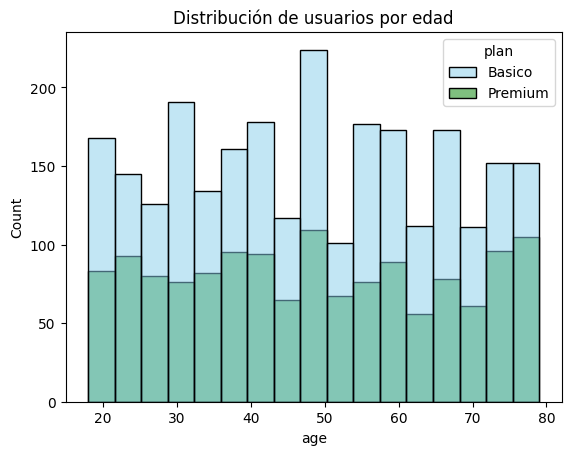

In [263]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x=user_profile["age"], hue="plan",palette=["skyblue","green"]).set(title = "Distribución de usuarios por edad")

plt.show()

💡Insights: 
- A pesar de reflejar sesgos, se evidencian picos en los usuarios de 30 y 50 años. Sin embargo, es importante considerar que las edades presentan una distribución uniforme
- Los usuarios con mayor tendencia a adquirir el plan premium son adultos mayores y en su edad media (30, 40, 50, 80) 

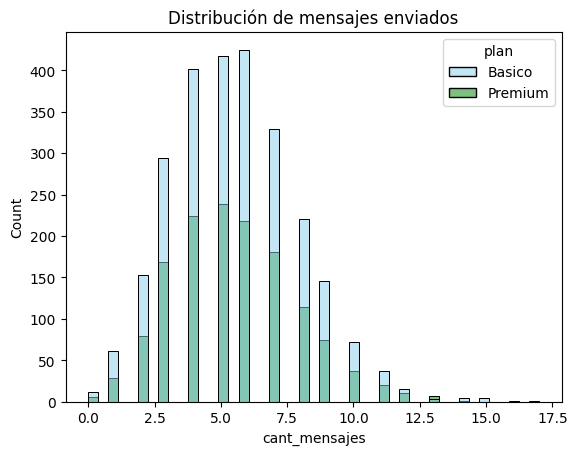

In [264]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x=user_profile["cant_mensajes"], hue="plan",palette=["skyblue","green"]).set(title="Distribución de mensajes enviados")
plt.show()



💡Insights: 
- A pesar de presentar un sesgo a la derecha, estos pocos registros que evidencian una cantidad alta de mensajes enviados no reflejan (al menos en un primer momento) valores extremos o poco probables

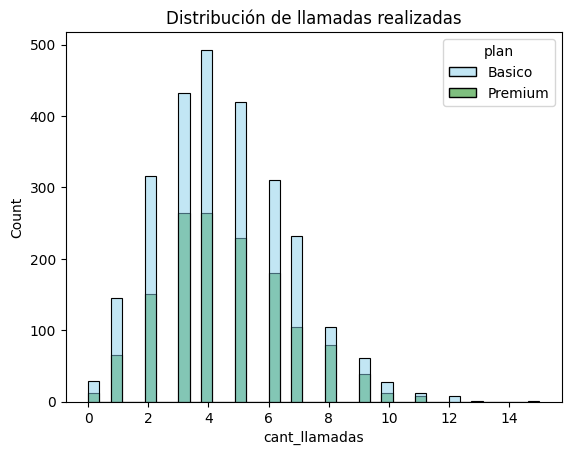

In [265]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x=user_profile["cant_llamadas"], hue="plan",palette=["skyblue","green"]).set(title="Distribución de llamadas realizadas")
plt.show()


💡Insights: 
- A pesar de presentar un sesgo a la derecha, estos pocos registros que evidencian una cantidad alta de mensajes enviados no reflejan (al menos en un primer momento) valores extremos o poco probables

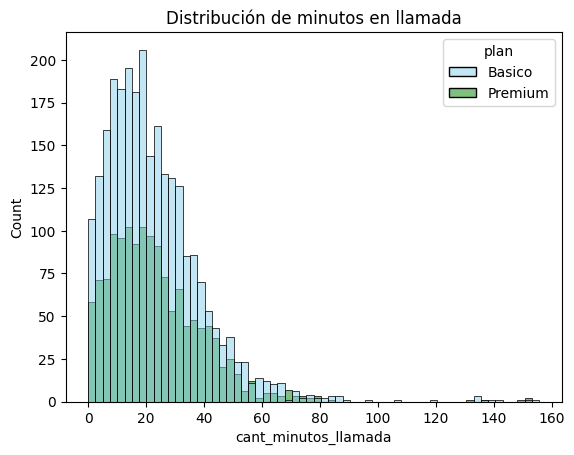

In [266]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x=user_profile["cant_minutos_llamada"], hue="plan",palette=["skyblue","green"]).set(title="Distribución de minutos en llamada")
plt.show()


💡Insights: 
- Unos pocos usuarios presentan una cantidad de minutos en llamada que crea un sesgo a la derecha, lo cual, considerando que los registros se encuentran mayormente agrupados, puede indicarnos que estos valores deben ser revisados a detalle

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

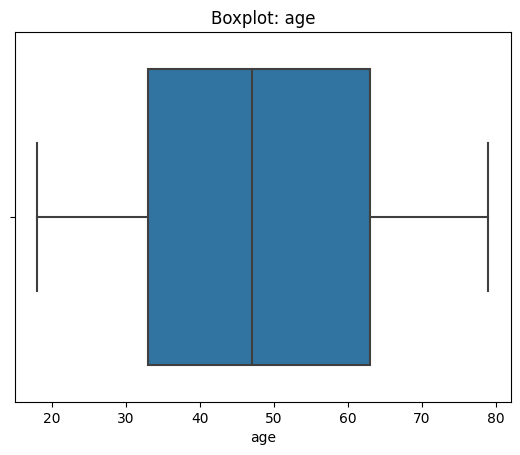

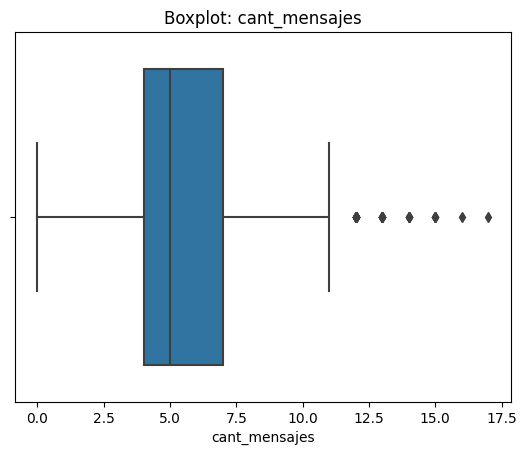

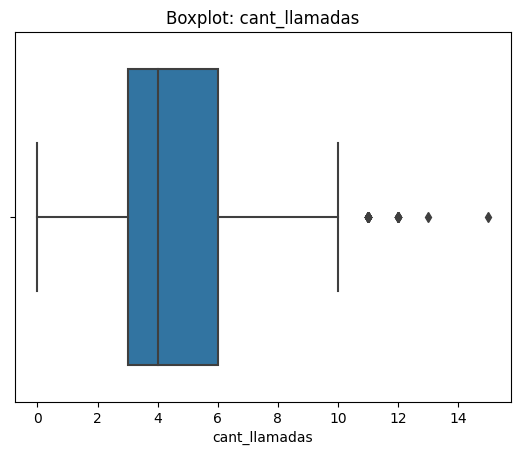

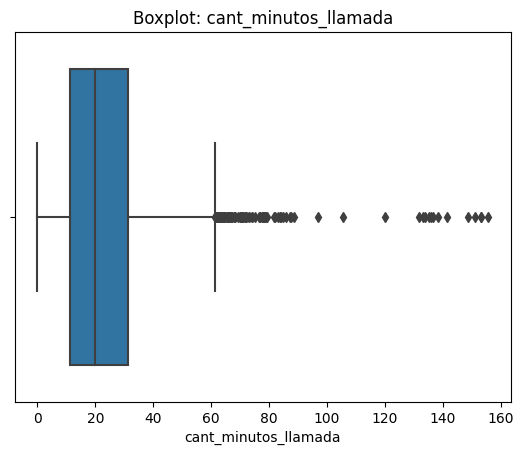

In [267]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: No presenta outliers
- cant_llamadas: No presenta outliers
- cant_minutos_llamada: Presenta valores extremos que si bien son posibles, es muy probable que se trate de outliers

In [268]:
#Función de prueba 
"""# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

def calculo_iqr(df,columns):

    for col in columns:
        primer_cuartil= df[col].quantile(0.25)
        tercer_cuartil= df[col].quantile(0.75)
        IQR = tercer_cuartil - primer_cuartil
        lower_limit= max(0, primer_cuartil - 1.5 * IQR)
        upper_limit= tercer_cuartil + 1.5 * IQR
        
        print(f"Límites de {col.capitalize()}")
        print(f"El primer cuartil de la columna {col} es: {primer_cuartil:.2f}")
        print(f"El tercer cuartil de la columna {col} es: {tercer_cuartil:.2f}")
        print(f"El IQR de la columna {col} es: {IQR}")
        print(f"El límite inferior de la columna {col} es: {lower_limit}")
        print(f"El límite superior de la columna {col} es: {upper_limit:.2f}\n")
        
calculo_iqr(user_profile, columnas_limites)
"""

'# Calcular límites con el método IQR\ncolumnas_limites = [\'age\', \'cant_mensajes\', \'cant_llamadas\', \'cant_minutos_llamada\']\n\ndef calculo_iqr(df,columns):\n\n    for col in columns:\n        primer_cuartil= df[col].quantile(0.25)\n        tercer_cuartil= df[col].quantile(0.75)\n        IQR = tercer_cuartil - primer_cuartil\n        lower_limit= max(0, primer_cuartil - 1.5 * IQR)\n        upper_limit= tercer_cuartil + 1.5 * IQR\n        \n        print(f"Límites de {col.capitalize()}")\n        print(f"El primer cuartil de la columna {col} es: {primer_cuartil:.2f}")\n        print(f"El tercer cuartil de la columna {col} es: {tercer_cuartil:.2f}")\n        print(f"El IQR de la columna {col} es: {IQR}")\n        print(f"El límite inferior de la columna {col} es: {lower_limit}")\n        print(f"El límite superior de la columna {col} es: {upper_limit:.2f}\n")\n        \ncalculo_iqr(user_profile, columnas_limites)\n'

In [269]:
#Función
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

def calculo_iqr_df(df, columns):
    # Lista para almacenar los resultados de cada columna
    resultados = []
    
    for col in columns:
        primer_cuartil = df[col].quantile(0.25)
        tercer_cuartil = df[col].quantile(0.75)
        IQR = tercer_cuartil - primer_cuartil
        lower_limit = max(0, primer_cuartil - 1.5 * IQR)
        upper_limit = tercer_cuartil + 1.5 * IQR
        
        # Guardamos las métricas en un diccionario por columna
        resultados.append({
            'Columna': col.capitalize(),
            'Primer Cuartil (Q1)': round(primer_cuartil, 2),
            'Tercer Cuartil (Q3)': round(tercer_cuartil, 2),
            'IQR': round(IQR, 2),
            'Límite Inferior': round(lower_limit, 2),
            'Límite Superior': round(upper_limit, 2)
        })
    
    # Convertimos la lista de diccionarios en un DataFrame
    df_resultados = pd.DataFrame(resultados)
    return df_resultados

# Para ejecutarlo y guardar el DataFrame:
df_limites = calculo_iqr_df(user_profile, columnas_limites)

df_limites


,Columna,Primer Cuartil (Q1),Tercer Cuartil (Q3),IQR,Límite Inferior,Límite Superior
0,Age,33.0,63.00,30.00,0,108.00
1,Cant_mensajes,4.0,7.00,3.00,0,11.50
2,Cant_llamadas,3.0,6.00,3.00,0,10.50
3,Cant_minutos_llamada,11.1,31.18,20.09,0,61.32


In [270]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,22.836934
std,17.690408,2.358416,2.144238,16.590213
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.095000
50%,47.000000,5.000000,4.000000,19.740000
75%,63.000000,7.000000,6.000000,31.185000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Podemos mantener los "outliers" ya que además de ser posibles, solo se apartan del límite superior ≈6%
- cant_llamadas: Podemos mantener los "outliers" ya que además de ser posibles, solo se apartan del límite superior ≈5%
- cant_minutos_llamada: El analisis indica que los outliers de esta columna pueden ser eliminados, sin embargo, es pertinente hacer una investigación adicional que permita determinar si son errorres de captura o hay una acción por parte de determinados usuarios que este generando este sesgo

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [272]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Uso medio
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [273]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [274]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),  # Joven
    (user_profile['age'] < 60) & (user_profile['cant_mensajes'] < 10) #Adulto
]

opciones = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, opciones, default='Adulto Mayor')

In [275]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

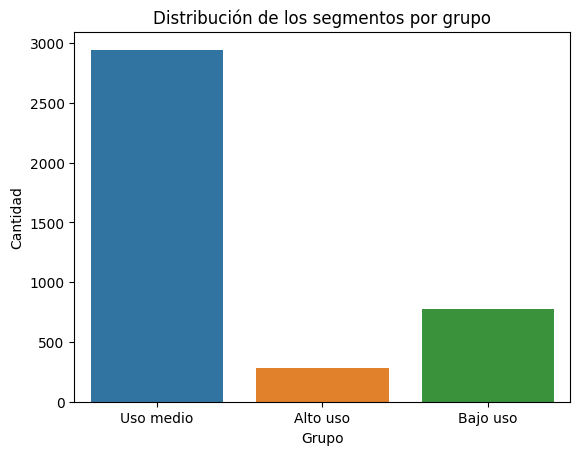

In [282]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")

plt.title("Distribución de los segmentos por grupo")
plt.xlabel("Grupo")
plt.ylabel("Cantidad")
plt.show()

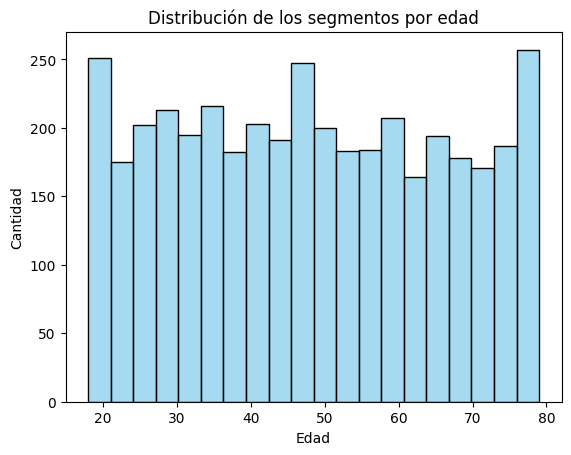

In [281]:
# Visualización de los segmentos por edad
sns.histplot(data=user_profile, x="age", bins=20, kde=False, color="skyblue")


plt.title("Distribución de los segmentos por edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo


⚠️ **Problemas detectados en los datos**
- Se identificaron registros con fechas de contratación fuera del rango operativo histórico de la campaña (2022-2024). Estas anomalías fueron tratadas convirtiéndolas a valores nulos (NaN) para evitar sesgos temporales. Asimismo, se detectaron códigos centinela en variables clave, los cuales fueron imputados utilizando la mediana de la distribución para preservar la robustez estadística sin alterar la tendencia central.
- Al evaluar las variables de tráfico (cant_llamadas y cant_mensajes) mediante el método estadístico de Rango Intercuartílico (IQR), se evidenciaron valores atípicos extremos. El límite superior de edad se estableció en 108 años según el cálculo matemático, lo que permitió identificar registros sospechosos (posibles errores de digitación o cuentas corporativas/fraude) que requerían aislamiento para no distorsionar las métricas promedio.


🔍 **Segmentos por Edad**
- Al dividir la base de usuarios en Jóvenes, Adultos y Adultos Mayores, se observó una correlación directa entre la edad y el tipo de plan seleccionado. Mientras que el segmento Joven muestra una inclinación hacia el plan Premium (potenciado por la necesidad de mayor capacidad de GB incluidos), el segmento de Adultos Mayores mantiene una concentración mayoritaria en el plan Básico.
- Contrario a la suposición tradicional de que los jóvenes monopolizan el uso de la red, los datos revelan que el segmento de Adultos mantiene una estabilidad crítica en el volumen de llamadas, convirtiéndose en el núcleo de retención del servicio de voz de ConnectaTel, mientras que los Jóvenes concentran su actividad casi exclusivamente en canales digitales. 


📊 **Segmentos por Nivel de Uso**
- Tras aplicar las reglas lógicas para clasificar a los usuarios en 'Bajo', 'Medio' y 'Alto' uso, se descubrió que una parte significativa de la base de datos se sitúa en la categoría de 'Bajo uso' (menos de 5 llamadas y 5 mensajes), lo que indica una subutilización de los recursos asignados en sus planes actuales.
- 'Alto Uso': Este subgrupo representa la mayor rentabilidad para la empresa, pero también el mayor riesgo de saturación o insatisfacción si agotan los beneficios de su plan. Se intersecta fuertemente con usuarios que poseen el plan Premium, validando que el diseño de este plan responde a una necesidad real de alto consumo.


➡️ Esto sugiere que: Existe una brecha de optimización comercial en ConnectaTel. Muchos usuarios están pagando por planes que no se alinean con su comportamiento real (usuarios en 'Bajo uso' con planes Premium, o Adultos Mayores con planes subutilizados). Además, la presencia de anomalías temporales y outliers resalta la necesidad de implementar reglas de validación en los formularios de registro de clientes (como restringir las fechas de entrada al periodo vigente) para evitar que la data operativa se ensucie desde el origen.


💡 **Recomendaciones**
- Evolución del Plan Básico para Adultos Mayores: Crear un módulo o "paquete de extensión" para el plan Básico enfocado en minutos de voz ilimitados o preferenciales, capturando el valor del segmento de Adultos y Adultos Mayores que priorizan las llamadas tradicionales sobre el consumo intensivo de datos.
- Estrategia de Downselling y Migración Guiada: Para el segmento detectado en 'Bajo uso', se sugiere diseñar una campaña de comunicación proactiva que les ofrezca planes de menor costo pero ajustados a su consumo real, mejorando la confianza y la retención del cliente a largo plazo (reducción de churn).
- Automatización de Alertas de Consumo Atípico (Monitoreo de Outliers): Implementar en los sistemas de ConnectaTel el script basado en el método IQR desarrollado en este análisis para generar alertas automáticas cuando un usuario supere el límite superior calculado. Esto servirá como un escudo temprano para detectar posibles fraudes o reventa ilegal de minutos. 


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/samuelgomez09/telecom-user-behavior-analysis.git